# **SIREX - Sistema Integrado de Regionalização de Vazões e Extremos Hidrológicos de Santa Catarina**

## **Segurança Hídrica**

A segurança hídrica tornou-se um dos maiores desafios contemporâneos para a gestão pública, diante do aumento da demanda por água, da intensificação da poluição e dos eventos extremos cada vez mais frequentes. Definida como a garantia de acesso sustentável à água em quantidade e qualidade adequadas para o bem-estar humano, o desenvolvimento econômico e a preservação ambiental, sua relevância estratégica é incontestável. Nesse contexto, quantificar a segurança hídrica torna-se condição indispensável para a tomada de decisões baseada em evidências. Mais que um conceito, a segurança hídrica precisa ser medida para que políticas públicas sejam efetivas, resilientes e comprometidas com o futuro.

In [1]:
# Importar funções do módulo utilitário
from sirex_utils import carregar_dados, plot_indicador, criar_legenda_horizontal, criar_interface_interativa

In [2]:
# Carregar shapefile
gdf = carregar_dados("Otto_Overall_SC.shp")
print("Dados carregados.")

Dados carregados.


### **Temporal Water Security Index - SC**

O Temporal Water Security Index – SC, originalmente desenvolvido por Fonseca et al. (2026), foi adaptado para a realidade do estado de Santa Catarina como ferramenta diagnóstica e de suporte à decisão. O índice estrutura-se em quatro dimensões interdependentes: humana, econômica, ecossistêmica e resiliência, operacionalizadas por meio de sete indicadores estratégicos: População, Rede de Abastecimento, Agricultura, Produção Suína, Qualidade da Água, Cheias e Secas. Essa arquitetura permite capturar, de forma integrada e espacialmente explícita, as múltiplas pressões sobre os recursos hídricos catarinenses.

<div align="center">
  <img src="framework.png" width="400" alt="Framework">
</div>

### **Indicador #1 - População**

**O que representa?**

Este indicador mostra, para cada região, a relação entre a quantidade de água que existe nos rios (disponibilidade) e o volume de água que é retirado para abastecer a população (demanda). Ele traduz, de forma prática, o “estresse hídrico” vivido pelas pessoas.

**Como foi calculado?**
- A disponibilidade foi medida pela vazão dos rios que permanece disponível 95% do tempo (Q95) – ou seja, a água que está sempre presente, mesmo nos períodos de seca.\
- A demanda veio dos dados oficiais de uso consuntivo da água (ANA), ajustados para cada bacia hidrográfica.\
- Com esses dois valores, calculou-se o balanço hídrico (demanda / disponibilidade) para cada município e bacia. Esse balanço foi então combinado com os dados populacionais do IBGE.\
- O resultado final expressa, por bacia, o quanto da água disponível está comprometida com o consumo humano.

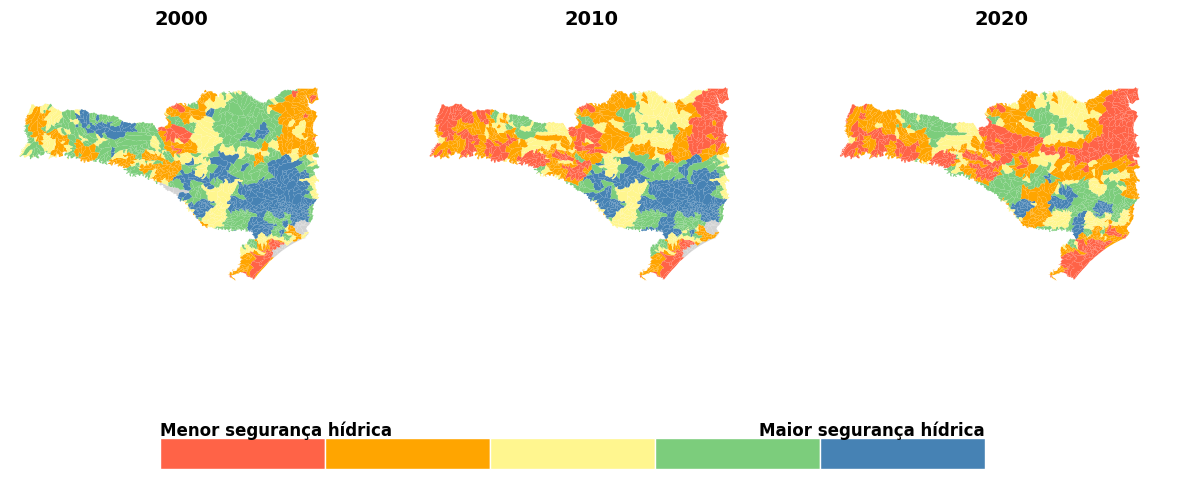

In [3]:
# Gerar mapas
plot_indicador(gdf, 'P_', 'Indicador #1 - População')

### **Indicador #2 - Rede de Abastecimento**

**O que representa?**

Mede, em porcentagem, a parcela da população de cada município que tem acesso à água tratada por meio da rede pública.

**Como foi calculado?**
- Foram utilizados dados oficiais do Sistema Nacional de Informações em Saneamento (SINISA), especificamente o índice de cobertura de abastecimento de água.
- As informações municipais foram agregadas para o nível das bacias hidrográficas, considerando a proporção da área de cada município dentro da bacia.

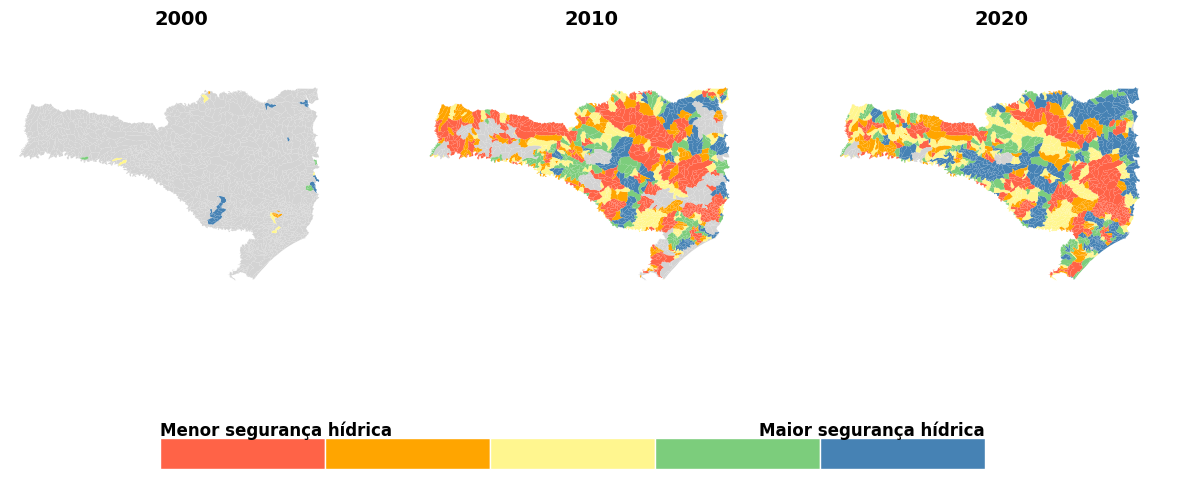

In [4]:
plot_indicador(gdf, 'S_', 'Indicador #2 - Rede de Abastecimento')

### **Indicador #3 - Agricultura**

**O que representa?**

Indica o nível de pressão sobre os recursos hídricos exercido pela atividade agrícola irrigada, especialmente nas culturas que mais consomem água: arroz, cana-de-açúcar e café.

**Como foi calculado?**
- O mesmo balanço hídrico (demanda / disponibilidade) foi utilizado, mas a demanda foi substituída pelos valores da produção agrícola municipal (IBGE), que representam a necessidade de irrigação.
- Esses dados foram cruzados com a disponibilidade de água nas bacias.\
- O resultado mostra, para cada bacia, se a demanda da agricultura está compatível com a oferta de água.

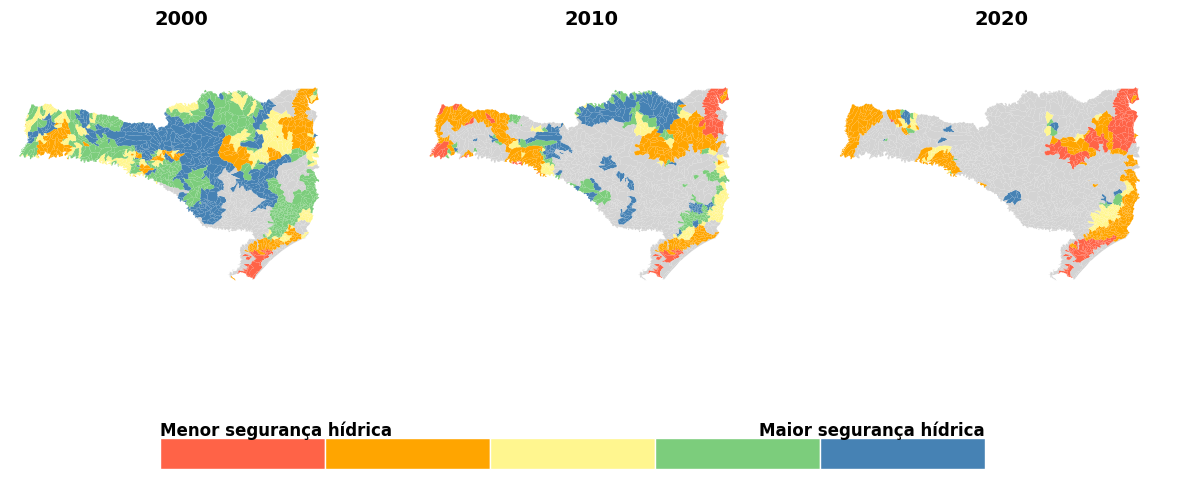

In [5]:
plot_indicador(gdf, 'A_', 'Indicador #3 - Agricultura')

### **Indicador #4 - Produção Suína**

**O que representa?**

Indica o nível de pressão sobre os recursos hídricos associado à atividade de produção suína nos municípios, considerando o volume de rebanho como proxy da demanda hídrica e da geração potencial de efluentes. A suinocultura é uma atividade intensiva em uso de água, tanto para dessedentação animal quanto para limpeza das instalações, além de representar fonte relevante de carga orgânica nos corpos dágua.

**Como foi calculado?**
- O mesmo balanço hídrico (demanda / disponibilidade) foi utilizado, mas a demanda foi substituída pelos valores municipais do efetivo de suínos (IBGE).
- Esses dados foram cruzados com a disponibilidade de água nas bacias.
- O resultado mostra, para cada bacia, se a demanda da produção suína está compatível com a oferta de água.

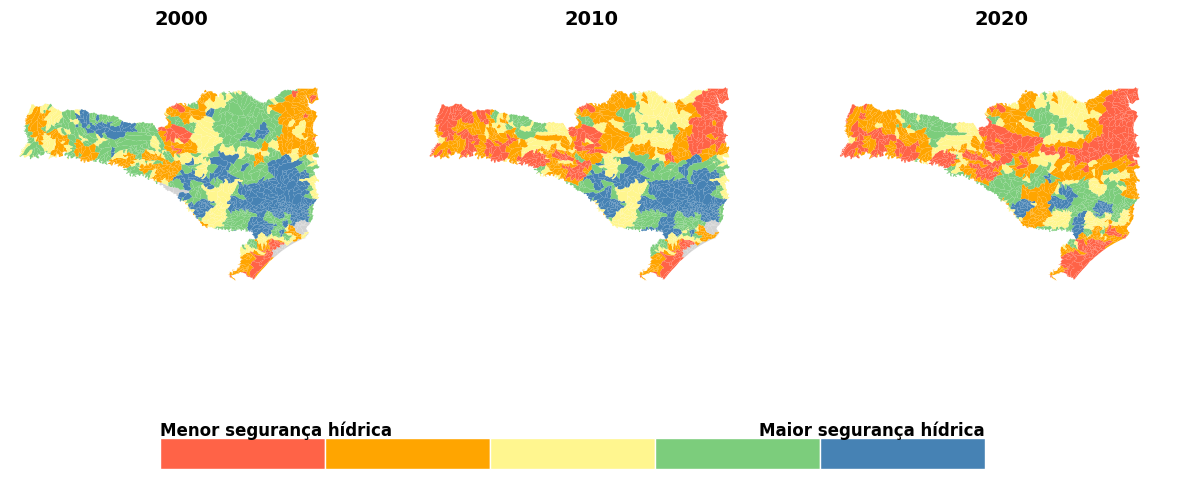

In [6]:
plot_indicador(gdf, 'P_', 'Indicador #4 - Produção Suína')

### **Indicador #5 - Qualidade de Água**

**O que representa?**
Este indicador traduz o nível de poluição das águas superficiais, utilizando a demanda bioquímica de oxigênio (DBO) como proxy. Quanto maior a DBO, maior a presença de esgoto e matéria orgânica — e pior a qualidade da água para consumo, lazer e ecossistemas.

**Como foi calculado?**
- Diferentemente dos demais, não foi possível reconstruir uma série histórica para este indicador devido à indisponibilidade de dados consistentes ao longo das décadas.
- Adotou-se diretamente o indicador de qualidade de água do Índice de Segurança Hídrica da ANA (2020) , que classifica os corpos d’água com base na DBO.
- O dado original foi integrado às Ottobacias e mantido constante para os três períodos analisados.

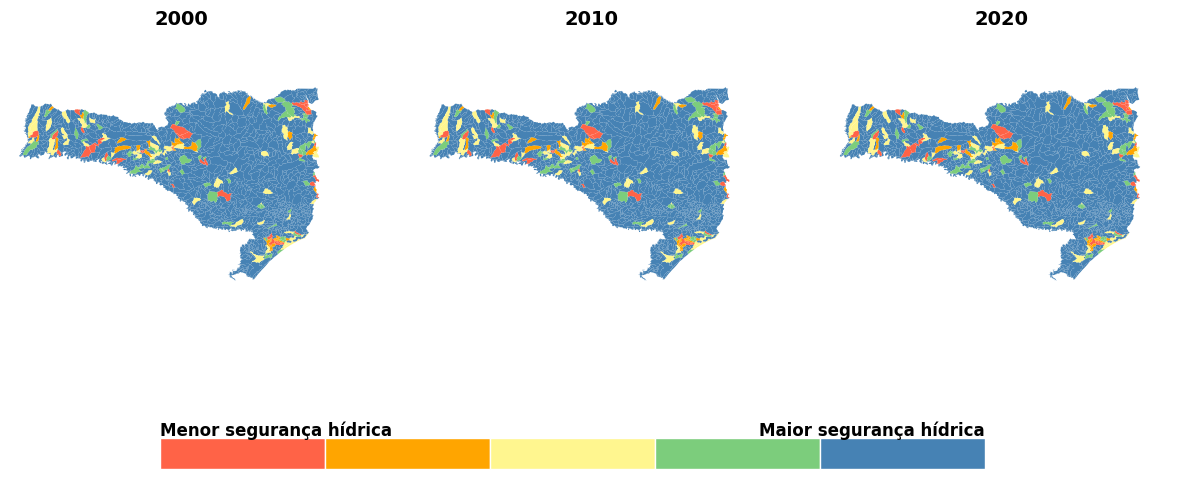

In [7]:
plot_indicador(gdf, 'Q_', 'Indicador #5 - Qualidade de Água')

### **Indicador #6 - Cheias**

**O que representa?**

Este indicador mapeia a frequência com que os rios ultrapassam o nível de transbordamento, identificando as regiões mais sujeitas a inundações. Ele traduz, em termos práticos, onde a população e a infraestrutura estão mais expostas a eventos extremos de cheia.

**Como foi calculado?**
- Para cada estação fluviométrica, estabeleceu-se um limiar de cheia (Q90): a vazão que é superada em apenas 10% do tempo. Esse valor funciona como uma referência estável, calculada a partir de toda a série histórica disponível.
- Foram identificados os eventos em que a vazão diária superou esse limiar, adotando-se um intervalo mínimo entre cheias para que cada evento fosse contabilizado uma única vez.
- A ocorrência de cheias foi então interpolada para todo o território nacional, gerando superfícies contínuas de risco.
- Os resultados foram agregados por bacia hidrográfica (Ottobacias), compatibilizando-os com os demais indicadores.

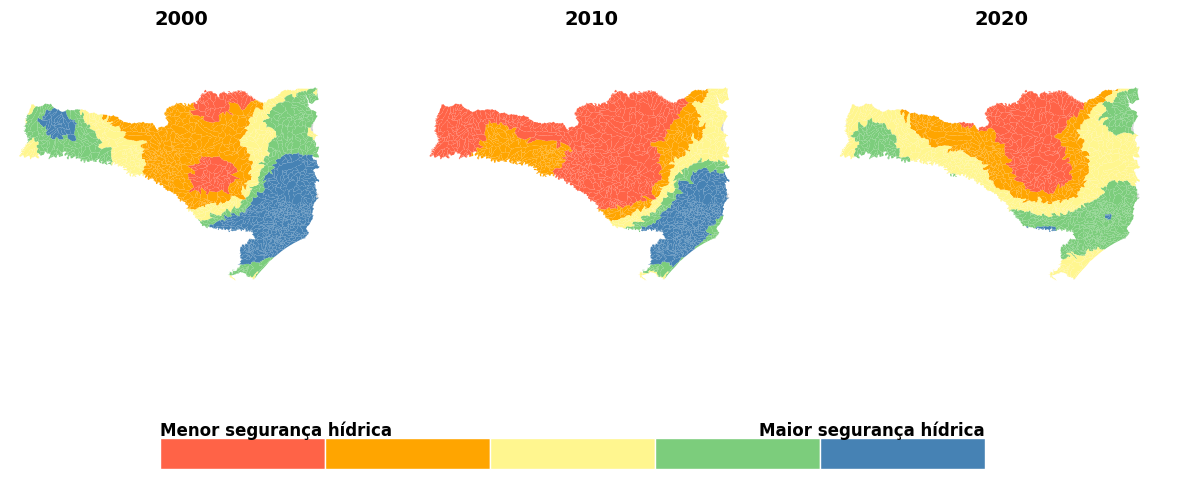

In [8]:
plot_indicador(gdf, 'F_', 'Indicador #6 - Cheias')

### **Indicador #7 - Secas**

**O que representa?**
Este indicador mede a duração média dos períodos de estiagem severa nos rios. Diferentemente da mera intensidade da seca, ele capta o tempo de resistência que a bacia impõe à população e às atividades econômicas durante eventos críticos.

**Como foi calculado?**\
- Para cada estação, definiu-se um limiar de seca (Q10): a vazão que é igualada ou superada em 90% do tempo. É o oposto do limiar de cheia — um patamar de escassez.
- Foram identificados os períodos em que a média móvel de 7 dias da vazão permaneceu abaixo desse limiar por pelo menos sete dias consecutivos.
- Calculou-se a duração média desses eventos para cada década.
- Esse dado foi interpolado e agregado por Ottobacia, gerando um mapa da persistência das secas em todo o Brasil.

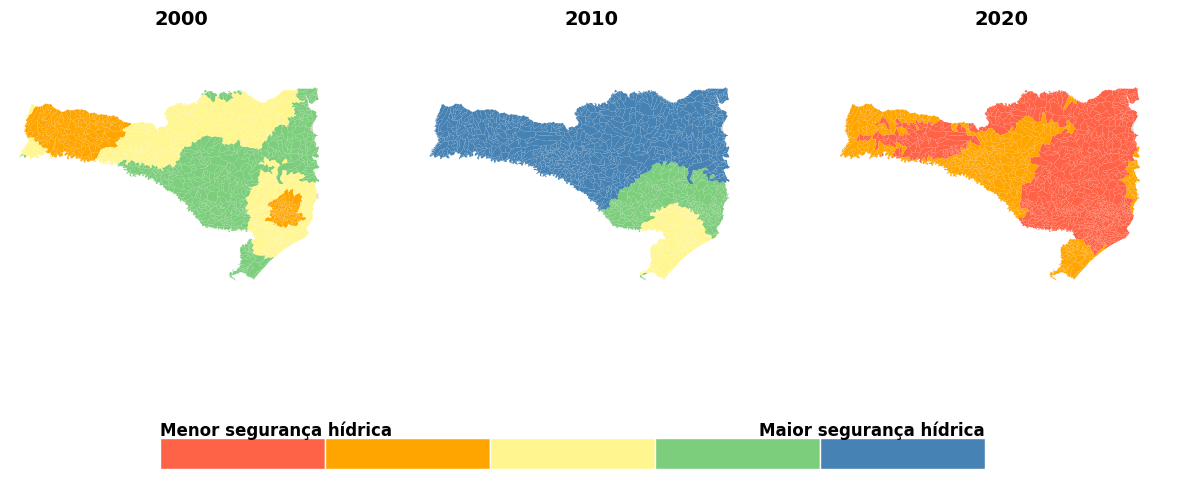

In [9]:
plot_indicador(gdf, 'D_', 'Indicador #7 - Secas')

### **Índice Geral**

**O que representa?**
É a nota final que sintetiza, numa escala de 1 a 5, o nível de segurança hídrica de cada bacia hidrográfica brasileira. Quanto mais próximo de 5, mais a bacia consegue garantir água em quantidade e qualidade para as pessoas, a economia e o meio ambiente, além de ser resiliente a extremos.

**Como foi calculado?**
- Cada um dos seis indicadores foi convertido para a escala comum de 1 a 5.
- Para a maioria, usaram-se quintis (20% das bacias em cada nível).
- Para cobertura de água, usaram-se faixas percentuais fixas.
- Para disponibilidade hídrica (população e agricultura), aplicou-se uma matriz de decisão que combina os valores totais e per capita.
- Os indicadores foram agrupados nas \*\*quatro dimensões da segurança hídrica: humana, econômica, ecossistêmica e resiliência.
- O índice final é a média aritmética simples das dimensões com dados disponíveis em cada bacia e década.

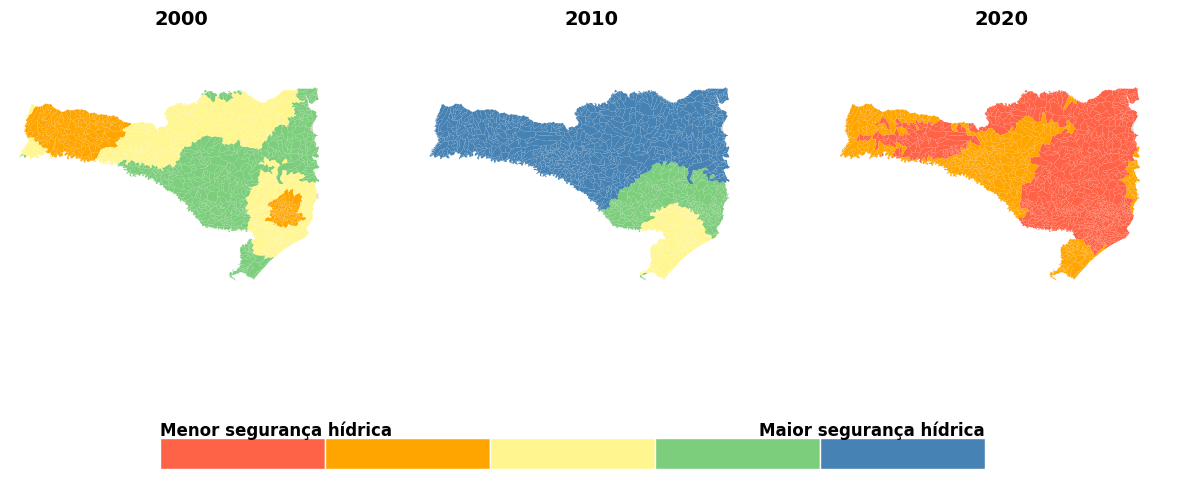

In [10]:
plot_indicador(gdf, 'D_', 'Indíce Geral')

### **Agora é a sua vez!**

Defina os pesos dos indicadores e dimensões do índice e veja o resultado da segurança hídrica para Santa Catarina.

In [11]:
# Criar interface interativa
controles, out, update = criar_interface_interativa(gdf)

# Exibir controles e área de saída
display(controles, out)

# Chamar atualização inicial
update()

Output()